# Analiza danych przestrzennych - ćwiczenia laboratoryjne 2025/2026

Ten notatnik zalicza się do grupy zestawów zadań, na podstawie których odbywa się zaliczenie ćwiczeń i podlega zwrotowi do oceny w ustalonym na zajęciach terminie.

Uwagi i wytyczne ogólne dotyczące uzupełniania i oceny notatnika:
- Podczas wykonywania zadań należy korzystać wyłącznie z pakietów zaimportowanych na początku notatnika oraz z pakietów wchodzących w skład standardowej biblioteki Pythona, które można zaimportować samodzielnie we wskazanej komórce notatnika.
- Swoje rozwiązania należy wprowadzać wyłącznie w miejce następujących fragmentów kodu:<br/> `# YOUR CODE HERE`<br/> `raise NotImplementedError()`<br/> 
a odpowiedzi tekstowe w komórkach oznaczonych hasłem:<br/> 
`YOUR ANSWER HERE`<br/> 
Nie należy w żaden sposób modyfikować pozostałych fragmentów kodu oraz innych elementów notatnika, w szczególności dodawać lub usuwać komórek oraz zmieniać nazwy pliku.
- Jeżeli zestaw zadań wymaga skorzystania z fragmentów kodu opracowanego w ramach wcześniejszych zestawów zadań należy je umieścić we wskazanej komórce notatnika.
- Otrzymywane wyniki i odpowiedzi mają być rezultatem wykonania napisanego kodu, odpowiedzi uzupełniane manualnie nie podlegają ocenie.
- Zawarte w notatniku automatyczne testy mają charakter poglądowy. Dotyczą one wybranych aspektów zadań i mają na celu wyłapać podstawowe błędy. Przejście przez kod wszystkich testów nie oznacza, że zadanie jest wykonane w całości poprawnie i zostanie ocenione na maksymalną liczbę punktów.
- Zadania należy wykonać w taki sposób, aby podczas wykonywania kodu nie zostały wyświetlone żadne ostrzeżenia.
- Zadania, które powodują wyświetlenie komunikatu o błędzie przerywającym wykonywanie kodu nie podlegają ocenie.
- W treści niektórych zadań mogą znaleźć się przykładowe schematy ich rozwiązania lub przykładowe schematy istotnych części rozwiązania. Nie zawsze są to rozwiązania optymalne pod kątem długości kodu lub prostoty rozwiązania.  Ich celem jest klarowne rozbicie pracy na kroki i ułatwienie samodzielnej weryfikacji wyników na każdym etapie. Należy je traktować wyłącznie poglądowo, a nie jako jedyne dopuszczalne rozwiązania. Ocenie podlega poprawność merytoryczna rozwiązania, jego kompletność oraz zgodność z wymaganiami, a nie konkretna forma zapisu.
- Dla zachowania przejrzystości i łatwego odnajdywania informacji w treści zadań podawane są pełne nazwy funkcji i klas wraz z nazwami pakietów (np. `pandas.read_csv()`, `geopandas.GeoDataFrame.to_crs`). W notatniku te same obiekty są dostępne przez skrótowe aliasy (np. `pd.read_csv()`, `gpd.GeoDataFrame.to_crs`).

Uwagi i wytyczne ogólne dotyczące wizualizacji wyników:
- Wszystkie wykresy powinny być wykonane w jednolitym, przejrzystym i czytelnym stylu, posiadać odpowiednio dobrane proporcje i zakresy wartości osi.
- Figury powinny mieć ustawione białe tło, tak, aby niezależnie od ustawień notatnika wszystkie elementy wykresów były dobrze widoczne (domyślnie tło jest przeźroczyste co może powodować problemy w notatnikach z ustawionym ciemnym tłem). Rozmiar poziomy figur nie powinien przekraczać 20 cali.
- Wykresy oraz ich osie powinny mieć nadane tytuły. Jeżeli w obrębie figury znajduje się więcej niż jeden wykres to figura również powinna mieć nadany tytuł.

Przed odesłaniem zestawu zadań do oceny proszę uzupełnić komórkę z danymi autorów rozwiązania (nazwa zespołu oraz imiona, nazwiska i numery indeksów członków zespołu) oraz upewnić się, że notatnik działa zgodnie z oczekiwaniami. W tym celu należy skorzystać z opcji **Restart Kernel and Run All Cells...** dostępnej na górnej belce notatnika pod symbolem $\blacktriangleright\blacktriangleright$.

Nazwa zespołu:
Członkowie:

---

## Zestaw zadań 10: Klasteryzacja i autokorelacja przestrzennna danych

In [23]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as cx

from pysal.lib import weights
from pysal.explore import esda

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, HDBSCAN
from matplotlib.colors import ListedColormap, BoundaryNorm

In [25]:
from sklearn.pipeline import Pipeline

### Wczytanie danych
Poniższy kod wczytuje do zmiennych `city`, `healthcare`, `sweden_data` oraz `districts_data` dane z pliku data.gpkg.

In [15]:
city = gpd.read_file("data.gpkg", layer='city')
city

,Nazwa,geometry
0,Kraków,"POLYGON ((571937.571 237575.079, 571934.41 237..."


In [16]:
healthcare = gpd.read_file("data.gpkg", layer='healthcare')
healthcare.head()

,geometry
0,POINT (567648.626 242679.161)
1,POINT (565324.881 245360.641)
2,POINT (571657.083 238891.309)
3,POINT (575026.424 244689.629)
4,POINT (576415.591 246533.94)


In [17]:
sweden_data = gpd.read_file("data.gpkg", layer='sweden_data')
sweden_data.head()

,Nazwa,geometry
0,Skåne län,"MULTIPOLYGON (((4578466.673 3717657.885, 45792..."
1,Blekinge län,"MULTIPOLYGON (((4696473.483 3703084.086, 46963..."
2,Kronobergs län,"MULTIPOLYGON (((4632645.506 3802767.507, 46331..."
3,Hallands län,"MULTIPOLYGON (((4460469.928 3829549.031, 44604..."
4,Västra Götalands län,"MULTIPOLYGON (((4448860.421 4019224.4, 4449098..."


In [18]:
districts_data = gpd.read_file("data.gpkg", layer='districts_data')
districts_data.head()

,Nazwa,Czytelnicy bibliotek (2023),Nowe mieszkania na 10tyś mieszkańców (2023),Gęstość zaludnienia (2023),Wskaźnik obciążenia demograficznego (2023),Przyrost naturalny (2023),Lesistość (2023),Saldo migracji (2023),Ludność w wieku przedprodukcyjnym (2023),Ludność w wieku produkcyjnym (2023),Ludność w wieku poprodukcyjnym (2023),geometry
0,powiat bolesławiecki,115.0,45.2,67.2,71.5,-3.85,59.2,0.3,17.8,58.3,23.9,"MULTIPOLYGON (((278695.74 398348.843, 278695.6..."
1,powiat dzierżoniowski,108.0,39.8,198.0,76.2,-9.53,20.6,-1.9,15.6,56.8,27.7,"MULTIPOLYGON (((346955.102 313769.706, 346846...."
2,powiat głogowski,93.0,24.4,191.9,76.4,-4.39,22.2,-3.4,18.0,56.7,25.4,"MULTIPOLYGON (((298734.283 417178.027, 298745...."
3,powiat górowski,110.0,22.1,44.0,71.4,-5.81,28.7,-3.7,17.5,58.3,24.1,"MULTIPOLYGON (((337018.116 424268.419, 337046...."
4,powiat jaworski,107.0,30.0,81.2,74.2,-6.52,22.0,-2.4,16.8,57.4,25.8,"MULTIPOLYGON (((303741.051 350450.818, 303749...."


### Funkcje wykorzystywane w komórkach testowych

In [19]:
def custom_cmap(max_label, noise_color="#d9d9d9"):
    tab20 = plt.get_cmap("Paired")
    hsv = plt.get_cmap("hsv")

    colors = [noise_color]

    for i in range(max_label + 1):
        if i < tab20.N:
            colors.append(tab20(i))
        else:
            colors.append(hsv((i - tab20.N) / (max_label - tab20.N + 1)))

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(
        boundaries=np.arange(-1.5, max_label + 1.5, 1),
        ncolors=cmap.N
    )
    return cmap, norm

cmap, norm = custom_cmap(20)

### Zadanie 1: Klasteryzacja danych przestrzennych [12 pkt]

Zmienna `healthcare` zawiera zbiór danych punktowych reprezentujących lokalizacje obiektów ochrony zdrowia (szpitale, przychodnie, apteki itp.) na terenie Krakowa. Zbiór ten zawiera struktury o zróżnicowanym charakterze przestrzennym, w szczególności klastry o zróżnicowanej wielkości, kształcie i gęstości oraz obserwacje odstające (szum).

#### a) Przeprowadzenie klasteryzacji

Wykonaj klasteryzację tego zbioru danych przy użyciu czterech różnych metod:
- k-średnich `sklearn.cluster.KMeans()`,
- klasteryzacja hierarchiczna `sklearn.cluster.AgglomerativeClustering()`,
- DBSCAN `sklearn.cluster.DBSCAN()`,
- HDBSCAN `sklearn.cluster.HDBSCAN()`,

Dla każdej metody dobierz wartości parametrów w sposób uzasadniony charakterem danych i możliwościami danej metody tak, aby uzyskać możliwie najlepszy wynik. Zwróć jednak uwagę, że nie każda metoda klasteryzacji jest w stanie uzyskać dla tego zestawu danych w pełni satysfakcjonujący wynik.

Algorytm postępowania:
1. Korzystając z własności `geopandas.GeoDataFrame.geometry.x` i `geopandas.GeoDataFrame.geometry.y` wyodrębnij z geometrii rozkładu współrzędne X i Y poszczególnych punktów. Następnie korzystajac z `numpy.vstack()` lub `numpy.concatenate()` oraz transpozycji skonstruuj macierz współrzędnych o wymiarach `(n, 2)`, gdzie n to liczba punktów rozkładu.
2. Korzystając z wymienionych wyżej klas oraz przynależnych do nich funkcji `fit_predict()` (np. `sklearn.cluster.KMeans.fit_predict()`) dokonaj klasteryzacji zestawu danych. Każdorazowo dobierz wartości parametrów w sposób uzasadniony charakterem danych i możliwościami danej metody tak, aby uzyskać możliwie najlepszy wynik. Na tym etapie rozważ następujące parametry (niebędne minimum):
    - k-średnich: `n_clusters`;
    - klasteryzacja hierarchiczna: , `linkage`, `n_clusters` lub `distance_threshold` (dwa ostatnie stosowane zamiennie);
    - DBSCAN: `eps`, `min_samples`;
    - HDBSCAN: `min_cluster_size`, `min_samples`, `cluster_selection_epsilon`, `max_cluster_size`;
4. Zapisz wynik klasteryzacji do kolumny tablicy `healthcare` o odpowiedniej nazwie (KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN).

In [26]:
x = healthcare.geometry.x
y = healthcare.geometry.y

macierz = np.vstack((x,y)).T

kmeans_pipeline = Pipeline([
    ("kmeans", KMeans(
        n_clusters=8,
        n_init=20
    ))
])

healthcare["KMeans"] = kmeans_pipeline.fit_predict(macierz)

agg_pipeline = Pipeline([
    ("agg", AgglomerativeClustering(
        n_clusters=7,
        linkage="ward" 
    ))
])

healthcare["AgglomerativeClustering"] = agg_pipeline.fit_predict(macierz)

dbscan_pipeline = Pipeline([
    ("dbscan", DBSCAN(
        eps=620,
        min_samples=5
    ))
])

healthcare["DBSCAN"] = dbscan_pipeline.fit_predict(macierz)

hdbscan_pipeline = Pipeline([
    ("hdbscan", HDBSCAN(
        min_cluster_size=5,
        cluster_selection_epsilon = 655
    ))
])

healthcare["HDBSCAN"] = hdbscan_pipeline.fit_predict(macierz)

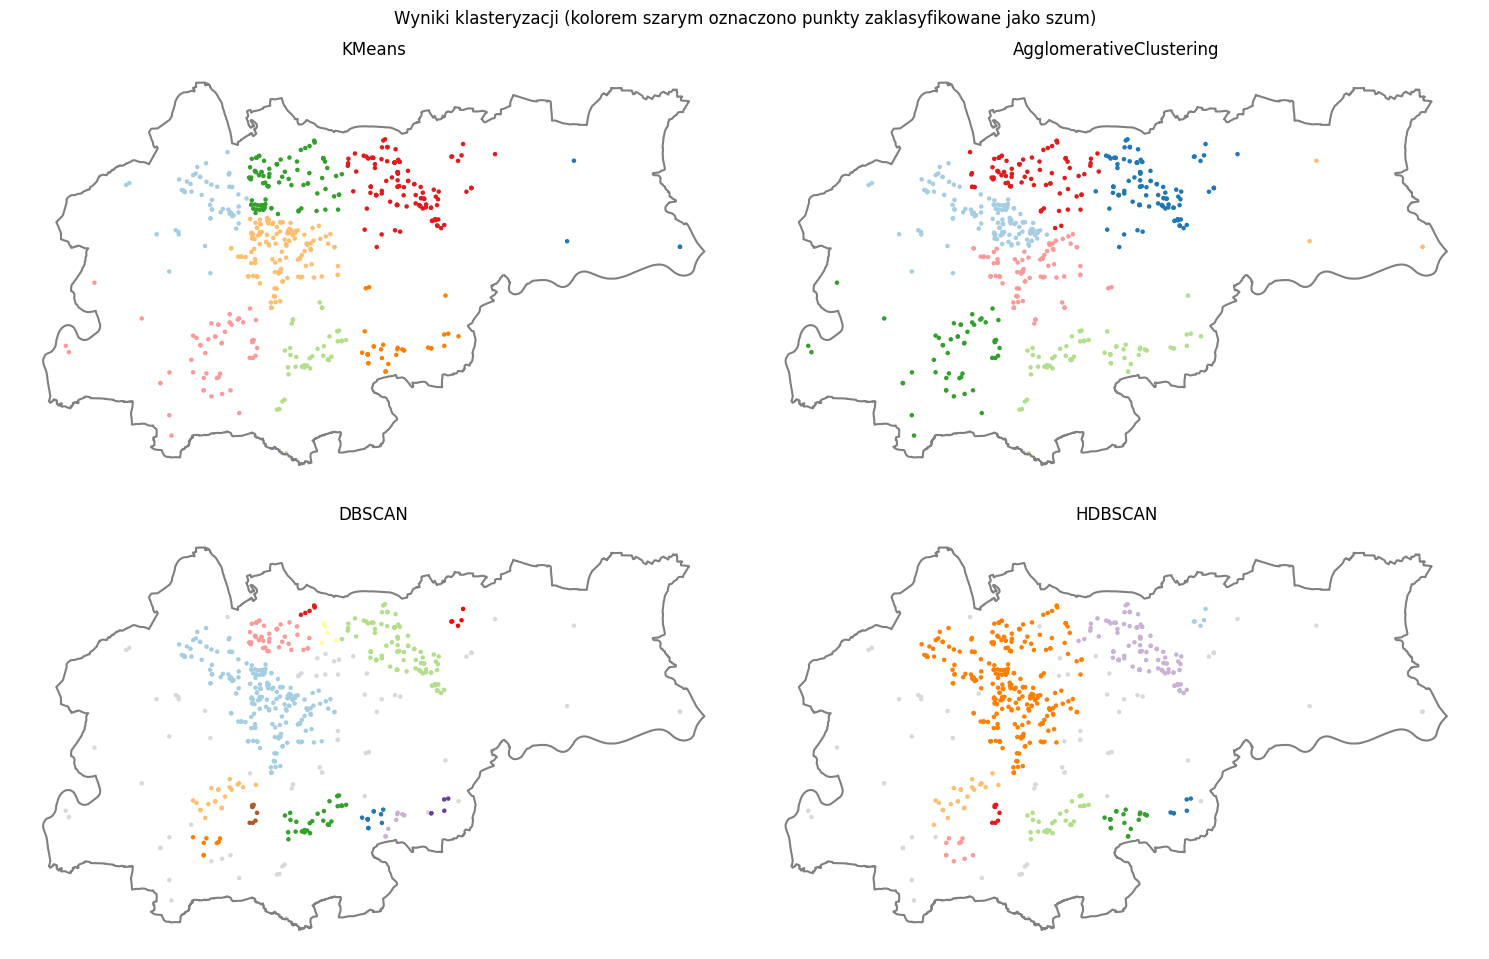

In [27]:
# Komórka testowa 
columns = ['KMeans', 'AgglomerativeClustering', 'DBSCAN', 'HDBSCAN']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle("Wyniki klasteryzacji (kolorem szarym oznaczono punkty zaklasyfikowane jako szum)")

for i, ax in enumerate(axes.flat):
    ax.set_title(columns[i])    
    city.boundary.plot(ax=ax, color="grey")
    ax.set_axis_off()
    try:
        healthcare.plot(ax=ax, column=columns[i], cmap=cmap, norm=norm, markersize=5, legend=False)
    except:
        pass

plt.tight_layout()
assert type(healthcare) == gpd.GeoDataFrame
assert healthcare.shape == (542, 5)
assert set(healthcare.columns) == set(['geometry', 'KMeans', 'AgglomerativeClustering', 'DBSCAN', 'HDBSCAN'])
assert np.all(np.isclose(healthcare[['KMeans', 'AgglomerativeClustering', 'DBSCAN', 'HDBSCAN']].min().values, np.array([ 0,  0, -1, -1])))

#### b) Uzasadnienie i ocena wyników

Krótko (kilka zdań dla każdej metody):
 - Uzasadnij dobór parametrów z punktu widzenia charakteru danych przestrzennych oraz założeń i ograniczeń danej metody klasteryzacji.
 - Oceń jakość otrzymanego wyniku:
     - czy metoda poprawnie identyfikuje klastry o różnej wielkości, gęstości i kształcie,
     - czy potrafi wykryć szum,
     - czy przyjęte założenia (np. liczba klastrów) są realistyczne w tym problemie,
     - itd.

### 1. KMeans
* **Uzasadnienie:** Wybór `n_clusters=8` narzuca sztywny podział przestrzeni na zbliżone wielkością obszary. Metoda dąży do minimalizacji wariancji wewnątrz klastrów, co w przypadku danych geograficznych tworzy klastry o kształtach zbliżonych do koła (poligony Woronoja).
* **Ocena:** Metoda **słabo radzi sobie** z tym zbiorem danych. Nie potrafi wykryć szumu (każda placówka, nawet odizolowana, musi należeć do klastra) i sztucznie dzieli gęste centrum miasta na mniejsze fragmenty, co nie oddaje naturalnej struktury usługowej.

### 2. AgglomerativeClustering
* **Uzasadnienie:** Parametr `linkage="ward"` minimalizuje przyrost całkowitej wariancji wewnątrzklastrowej. Przy `n_clusters=7` algorytm buduje hierarchię, łącząc najbliższe punkty w coraz większe grupy.
* **Ocena:** Wynik jest bardziej spójny przestrzennie niż w KMeans, ale algorytm nadal **wymusza przynależność** każdego punktu do grupy. Podobnie jak KMeans, ma trudności z identyfikacją klastrów o bardzo nieregularnych kształtach i różnej gęstości (np. rozciągnięte osiedla).

### 3. DBSCAN
* **Uzasadnienie:** `eps=620` (metry) oraz `min_samples=5` definiują klaster jako obszar o konkretnej gęstości minimalnej. To podejście czysto lokalne, idealne do wykrywania zagęszczeń infrastruktury.
* **Ocena:** Bardzo dobrze **identyfikuje szum** (szare punkty), co pozwala odfiltrować pojedyncze gabinety od dużych centrów medycznych. Jednak przy stałym promieniu `eps` algorytm "rozpada się" na wiele bardzo małych klastrów, nie potrafiąc połączyć obszarów o różnym stopniu zagęszczenia w jedną funkcjonalną całość.

### 4. HDBSCAN
* **Uzasadnienie:** `min_cluster_size=5` pozwala na automatyczne dopasowanie gęstości. Dzięki podejściu hierarchicznemu algorytm nie wymaga definiowania globalnego promienia, co jest kluczowe w miastach, gdzie centrum jest znacznie gęstsze niż obrzeża.
* **Ocena:** Metoda daje **najlepsze i najbardziej realistyczne wyniki**. Poprawnie identyfikuje główne jądro medyczne miasta (duży pomarańczowy klaster) oraz mniejsze skupiska satelitarne, jednocześnie skutecznie oznaczając odizolowane placówki jako szum.


### Zadanie 2: Macierz wag przestrzannych [7 pkt]

Zmienna `sweden_data` zawiera dane przedstawiające podział administracyjny Szwecji.

#### a) Generowanie macierzy wag przestrzennych

Utwórz trzy macierze wag przestrzennych za pomocą trzech metod:
1) `pysal.lib.weights.contiguity.Rook.from_dataframe()`;
2) `pysal.lib.weights.distance.KNN.from_dataframe()` przyporządkowując do każdego z obszarów 4 najbliższych sąsiadów;
3) `pysal.lib.weights.distance.DistanceBand.from_dataframe()` przyporządkowując do każdego z obszarów sąsiadów w promieniu 300km (liczone między centroidami obszarów).

Korzystając z powyższych funkcji każdorazowo ustaw argument `use_index=True`.
Zapisz wyniki do zmiennych `w_r`, `w_knn` i `w_db` oraz wyświetl liczbę sąsiadów poszczególnych obszarów korzystając z własności `cardinalities` (np. `weights.contiguity.Rook.cardinalities`). 

Uwaga! W przypadku, gdy algorytm ze względu na swoje ograniczenia lub dobór parametrów nie był w stanie dopasować sąsiadów do wszystkich obszarów wyświetlony zostanie komunikat `UserWarning: The weights matrix is not fully connected`. Nie należy się nim w takiej sytuacji przejmować.

In [31]:
w_r = weights.contiguity.Rook.from_dataframe(sweden_data, use_index=True)
w_r.cardinalities

{0: 3,
 1: 3,
 2: 5,
 3: 4,
 4: 5,
 5: 3,
 6: 4,
 7: 0,
 8: 5,
 9: 1,
 10: 2,
 11: 4,
 12: 4,
 13: 4,
 14: 3,
 15: 3,
 16: 5,
 17: 5,
 18: 6,
 19: 5,
 20: 4}

In [33]:
w_knn = weights.distance.KNN.from_dataframe(sweden_data, k=4, use_index=True)
w_knn.cardinalities

{0: 4,
 1: 4,
 2: 4,
 3: 4,
 4: 4,
 5: 4,
 6: 4,
 7: 4,
 8: 4,
 9: 4,
 10: 4,
 11: 4,
 12: 4,
 13: 4,
 14: 4,
 15: 4,
 16: 4,
 17: 4,
 18: 4,
 19: 4,
 20: 4}

In [35]:
w_db = weights.distance.DistanceBand.from_dataframe(sweden_data, 300_000, use_index=True)
w_db.cardinalities

{0: 7,
 1: 8,
 2: 10,
 3: 8,
 4: 11,
 5: 10,
 6: 12,
 7: 10,
 8: 13,
 9: 1,
 10: 10,
 11: 12,
 12: 9,
 13: 9,
 14: 4,
 15: 3,
 16: 12,
 17: 15,
 18: 14,
 19: 10,
 20: 4}

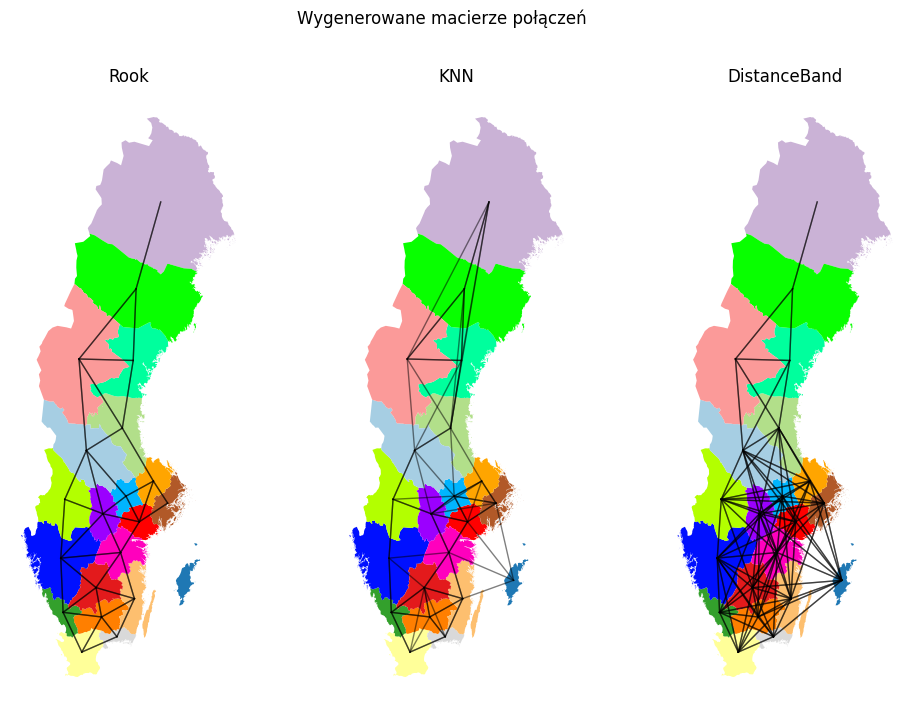

In [36]:
# Komórka testowa
fig, axes = plt.subplots(1, 3, figsize=(12, 8))

fig.suptitle("Wygenerowane macierze połączeń")

titles = ["Rook", "KNN", "DistanceBand"]
for i, ax in enumerate(axes.flat):
    ax.set_title(titles[i])    
    sweden_data.plot(ax=ax, column="Nazwa", cmap=cmap)
    ax.set_axis_off()

try:
    w_r.plot(sweden_data, ax=axes[0], edge_kws=dict(color='black', linewidth=1, alpha=0.5), node_kws=dict(marker=''))
except:
    pass

try:
    w_knn.plot(sweden_data, ax=axes[1], edge_kws=dict(color='black', linewidth=1, alpha=0.5), node_kws=dict(marker=''))
except:
    pass
    
try:
    w_db.plot(sweden_data, ax=axes[2], edge_kws=dict(color='black', linewidth=1, alpha=0.5), node_kws=dict(marker=''))
except:
    pass

assert type(w_r) == weights.contiguity.Rook
assert len(w_r.cardinalities) == 21
assert np.all(np.isclose(np.array(list(w_r.cardinalities.values())), np.array([3, 3, 5, 4, 5, 3, 4, 0, 5, 1, 2, 4, 4, 4, 3, 3, 5, 5, 6, 5, 4])))

assert type(w_knn) == weights.distance.KNN
assert len(w_knn.cardinalities) == 21
assert np.all(np.isclose(np.array(list(w_knn.cardinalities.values())), np.array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])))

assert type(w_db) == weights.distance.DistanceBand
assert len(w_db.cardinalities) == 21
assert np.all(np.isclose(np.array(list(w_db.cardinalities.values())), np.array([7,  8, 10,  8, 11, 10, 12, 10, 13,  1, 10, 12,  9,  9,  4,  3, 12, 15, 14, 10,  4])))

#### b) Analiza wyników

Krótko (kilka zdań dla każdej metody) oceń wygenerowane macierze wag przestrzennych. Odpowiedz jak poszczególne metody poradziły sobie z układem granic, obszarami przestrzennie izolowanymi oraz z różną wielkościa obszarów (duże jednostki na północy, mniejsze na południu).

Podczas oceny macierzy zwróć uwagę na fakt, że linie na grafice wygenerowanej w komórce testowej są półprzeźroczyste - w ziwązku z tym czarna linia oznacza, że obszary są wzajemnie swoimi sąsiadami, a linia szara, że relacja jest jednokierunkowa.

* **Rook** – dobrze odwzorowuje granice administracyjne (czarne linie), ale słabo radzi sobie z obszarami izolowanymi, np. wyspami, oraz dużymi jednostkami na północy, które mają niewielu sąsiadów.
* **KNN (K-Nearest Neighbors)** – każda jednostka ma dokładnie czterech sąsiadów, co sprawdza się w izolowanych regionach, ale relacje mogą być jednokierunkowe (szare linie) i nie zawsze odpowiadają rzeczywistej geografii dużych obszarów.
* **DistanceBand** – dobrze oddaje ciągłość przestrzenną w gęsto zabudowanych, mniejszych jednostkach, ale w północnych, rozległych obszarach liczba sąsiadów jest mniejsza; metoda ta jest wrażliwa na wybór promienia i nierównomierne rozmieszczenie jednostek.

### Zadanie 3: Autokorelacja przestrzenna danych [6 pkt]

Zmienna `districts_data` zawieraja geometrie powiatów oraz przypisane do nich statystyki.

### a) Obliczenie statystyk

Oblicz wartości statystyk Morana I oraz Geary’ego C dla dwóch zmiennych: salda migracji i przyrostu naturalnego.

Algorytm postępowania:
1) Korzystając z `pysal.lib.weights.contiguity.Rook.from_dataframe()` oblicz i zapisz do zmiennej `w` macierz wag przestrzennych.
2) Dla każdej ze statystyk:
     - korzystając z `pysal.explore.esda.moran.Moran()` wygeneruj obiekt zawierający wyniki obliczeń statystyki Morana;
     - korzystając z `pysal.explore.esda.geary.Geary()` wygeneruj obiekt zawierający wyniki obliczeń statystyki Geary’ego;

    Zapisz wyniki do zmiennych `moran_sm` i `geary_sm` (saldo migracji) oraz `moran_pn` i `moran_pn` (przyrost naturalny).
4) Zapisz do zmiennych oraz odpowiednich własności wygenerowanych obiektów:
    - wartość statystyki I: `pysal.explore.esda.moran.Moran.I`
    - wartość statystki C: `pysal.explore.esda.geary.Geary.C`
    - p-value: `pysal.explore.esda.moran.Moran.p_sim` oraz `pysal.explore.esda.geary.Geary.p_sim`
5) Wyświetl wyniki analiz za pomocą funkcji `print()` 

In [39]:
w = weights.contiguity.Rook.from_dataframe(districts_data, use_index=True)

saldo_migracji = districts_data['Saldo migracji (2023)'].values
przyrost_naturalny = districts_data['Przyrost naturalny (2023)'].values


In [40]:
# Saldo migracji
moran_sm = esda.moran.Moran(saldo_migracji, w)
geary_sm = esda.geary.Geary(saldo_migracji, w)

moran_I_sm = moran_sm.I
moran_p_sm = moran_sm.p_sim
geary_C_sm = geary_sm.C
geary_p_sm = geary_sm.p_sim

In [41]:
# Komórka testowa
assert np.isclose(moran_I_sm, 0.17418861971191557)
assert np.isclose(moran_p_sm, 0.001)
assert np.isclose(geary_C_sm, 0.9319430884750145)
assert geary_p_sm>0.05

In [42]:
moran_sm = esda.moran.Moran(przyrost_naturalny, w)
geary_sm = esda.geary.Geary(przyrost_naturalny, w)

moran_I_pn = moran_sm.I
moran_p_pn = moran_sm.p_sim
geary_C_pn = geary_sm.C
geary_p_pn = geary_sm.p_sim

In [43]:
# Komórka testowa
assert np.isclose(moran_I_pn, 0.484787731707421)
assert np.isclose(moran_p_pn, 0.001)
assert np.isclose(geary_C_pn, 0.5167537072706061)
assert np.isclose(geary_p_pn, 0.001)

#### b) Interpretacja wyników

Na podstawie uzyskanych wyników oceń, czy dla badanych zmiennych występuje istotna globalna autokorelacja przestrzenna oraz porównaj zachowanie statystyk Morana I i Geary’ego C. Interpretacja powinna uwzględniać znak i wartość statystyki Morana I, relację wartości statystyki Geary’ego C do 1 oraz poziomy istotności statystycznej. Podczas interpretacji przyjmij poziom istotności alpha=0.05.

## Ocena globalnej autokorelacji przestrzennej

### 1. Saldo migracji (2023)
* **Moran I = 0.174, p = 0.001** – słaba, ale istotna dodatnia autokorelacja globalna.
* **Geary C = 0.932, p = 0.089** – efekt nieistotny statystycznie; lokalne różnice przeważają.
* **Wniosek:** autokorelacja jest ogólnie słaba i niejednorodna.

### 2. Przyrost naturalny (2023)
* **Moran I = 0.485, p = 0.001, Geary C = 0.517, p = 0.001** – silna i istotna dodatnia autokorelacja; powiaty o podobnym przyroście naturalnym tworzą wyraźne skupiska.

### 3. Porównanie
* Moran I uwzględnia **globalną zgodność wartości**, Geary C reaguje na **lokalne różnice**.
* Dla salda migracji efekt jest słaby i rozproszony, dla przyrostu naturalnego – wyraźny i spójny przestrzennie.